# Backcasting threshold 0.729: load cached results and create figures

This reduced notebook does **not** create the binary raster, resample source rasters, calculate SHAP values, count raster pixels, or generate new samples. It loads previously written rasters, CSV files, pickle files, and GeoPackages and then recreates figures and summary tables.

Run the cells from top to bottom. A missing cache causes a clear `FileNotFoundError` rather than triggering an expensive recalculation.

In [1]:
# ============================================================
# 0. Imports, paths and load-only behaviour
# ============================================================

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import Normalize, TwoSlopeNorm
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    brier_score_loss,
)
from sklearn.calibration import calibration_curve
from scipy.stats import spearmanr

warnings.filterwarnings("ignore", category=FutureWarning)

FINAL_THRESHOLD = 0.729

BASE_DIR = Path("/mnt/eo/EO4Backcasting")
CACHE_DIR = BASE_DIR / "_analysis_cache"
FIGURE_DIR = BASE_DIR / "_figs" / "plotting_only_gt0729"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

BINARY_RASTER = (
    BASE_DIR
    / "_predictions/predictions_global_model/"
      "global_model_no_dist_gt0729_4conn_5ha_TRUE_0_1.tif"
)

COUNTRY_GPKG = BASE_DIR / "_data/CNTR_RG_10M_2024_3035.gpkg"

HEX_GPKG = (
    CACHE_DIR
    / "forest_continuity_gt0729_by_small_clipped_hexagon_lon45_gt0729.gpkg"
)

MODEL_PERFORMANCE_DIR = BASE_DIR / "_figs/model_performance_gt0729"
TEST_PREDICTIONS_CSV = MODEL_PERFORMANCE_DIR / "test_predictions.csv"

SHAP_CACHE_DIR = BASE_DIR / "_figures/shap/cache"
SHAP_FULL_PKL = SHAP_CACHE_DIR / "df_shap_full.pkl"
SHAP_IMPORTANCE_CSV = SHAP_CACHE_DIR / "shap_global_importance.csv"
SHAP_POINTS_GPKG = SHAP_CACHE_DIR / "shap_points_europe.gpkg"

GENUS_ANALYSIS_DIR = BASE_DIR / "_analysis/genus_observed_expected"
GENUS_FIGURE_DIR = GENUS_ANALYSIS_DIR / "figures"
GENUS_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

COUNTRY_GENUS_COUNTS_CSV = (
    CACHE_DIR / "country_genus_total_and_continuity_counts_gt0729.csv"
)
COUNTRY_SHARE_CSV = (
    CACHE_DIR / "continuously_undisturbed_share_by_country_gt0729.csv"
)
HEX_GENUS_RESULTS_CSV = (
    GENUS_ANALYSIS_DIR / "hex_genus_relative_representation_gt0729.csv"
)
HEX_GENUS_RESULTS_GPKG = (
    GENUS_ANALYSIS_DIR / "hex_genus_relative_representation_gt0729.gpkg"
)

FOREST_AGE_DIR = BASE_DIR / "_analysis/plausibility_checks_gt0729"
FOREST_AGE_SAMPLE_CSV = (
    FOREST_AGE_DIR
    / "forest_age_continuity_vs_disturbed_after_1995_sample_gt0729_v2.csv"
)
FOREST_AGE_HEX_GPKG = (
    FOREST_AGE_DIR
    / "forest_age_continuity_common_support_gt0729_v2.gpkg"
)
FOREST_AGE_SENSITIVITY_CSV = (
    FOREST_AGE_DIR
    / "forest_age_threshold_sensitivity_gt0729_v2.csv"
)

print("Plot-only mode")
print("Threshold:", FINAL_THRESHOLD)
print("Figure directory:", FIGURE_DIR)


Plot-only mode
Threshold: 0.729
Figure directory: /mnt/eo/EO4Backcasting/_figs/plotting_only_gt0729


In [2]:
# ============================================================
# 0.1 Safe loading helpers
# ============================================================

def require_file(path, label=None):
    path = Path(path)
    if not path.exists():
        name = label or path.name
        raise FileNotFoundError(
            f"{name} was not found:\n{path}\n"
            "This notebook will not recalculate it. "
            "Create it once in the complete analysis notebook."
        )
    return path


def read_first_gpkg_layer(path):
    path = require_file(path)
    try:
        import pyogrio
        layers = pyogrio.list_layers(path)
        layer = str(layers[0][0])
        print(f"Loading layer '{layer}' from {path.name}")
        return gpd.read_file(path, layer=layer)
    except Exception:
        return gpd.read_file(path)


def save_figure(fig, stem, dpi=400):
    stem = Path(stem)
    stem.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(stem.with_suffix(".png"), dpi=dpi, bbox_inches="tight", facecolor="white")
    fig.savefig(stem.with_suffix(".svg"), bbox_inches="tight", facecolor="white")
    print("Saved:", stem.with_suffix(".png"))
    print("Saved:", stem.with_suffix(".svg"))


def find_country_name_column(gdf):
    for candidate in ["NAME_ENGL", "CNTR_NAME", "NAME_EN", "NAME"]:
        if candidate in gdf.columns:
            return candidate
    raise ValueError(f"No country-name column found: {list(gdf.columns)}")


def load_countries(target_crs):
    countries = read_first_gpkg_layer(COUNTRY_GPKG)
    countries = countries[
        countries.geometry.notna() & ~countries.geometry.is_empty
    ].copy()
    if countries.crs != target_crs:
        countries = countries.to_crs(target_crs)
    return countries


## 1. Load the final binary raster without recreating it

In [3]:
# Read metadata only. The raster is not thresholded or filtered here.
require_file(BINARY_RASTER, "Final binary continuity raster")

with rasterio.open(BINARY_RASTER) as src:
    print("Path:", src.name)
    print("CRS:", src.crs)
    print("Shape:", (src.height, src.width))
    print("Bounds:", src.bounds)
    print("Nodata:", src.nodata)
    print("Data type:", src.dtypes[0])


Path: /mnt/eo/EO4Backcasting/_predictions/predictions_global_model/global_model_no_dist_gt0729_4conn_5ha_TRUE_0_1.tif
CRS: EPSG:3035
Shape: (140000, 130000)
Bounds: BoundingBox(left=2612197.933345846, bottom=1365550.4228236396, right=6512197.933345846, top=5565550.42282364)
Nodata: 0.0
Data type: uint8


## 2. Model-performance figures from saved test predictions

In [4]:
# Load saved test predictions only
test_predictions = pd.read_csv(
    require_file(TEST_PREDICTIONS_CSV, "Saved test predictions")
)

label_candidates = [
    "label_undisturbed_20y",
    "label",
    "y_true",
]
label_col = next(
    (c for c in label_candidates if c in test_predictions.columns),
    None,
)

if label_col is None:
    raise ValueError(
        "No reference-label column found in test_predictions.csv. "
        f"Columns: {list(test_predictions.columns)}"
    )

prob_col = "predicted_probability"
if prob_col not in test_predictions.columns:
    raise ValueError(f"Missing column: {prob_col}")

y_test = test_predictions[label_col].astype(int).to_numpy()
p_test = test_predictions[prob_col].astype(float).to_numpy()
y_test_pred = (p_test >= FINAL_THRESHOLD).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred, labels=[0, 1]).ravel()

precision = tp / (tp + fp) if (tp + fp) else np.nan
recall = tp / (tp + fn) if (tp + fn) else np.nan
specificity = tn / (tn + fp) if (tn + fp) else np.nan
fpr_value = fp / (fp + tn) if (fp + tn) else np.nan

metrics = pd.DataFrame({
    "metric": [
        "Threshold", "Precision", "Recall", "Specificity",
        "False-positive rate", "True negatives",
        "False positives", "False negatives", "True positives"
    ],
    "value": [
        FINAL_THRESHOLD, precision, recall, specificity,
        fpr_value, tn, fp, fn, tp
    ],
})

display(metrics)


,metric,value
0,Threshold,0.729000
1,Precision,0.870471
2,Recall,0.203596
3,Specificity,0.969406
4,False-positive rate,0.030594
5,True negatives,27979.000000
6,False positives,883.000000
7,False negatives,23212.000000
8,True positives,5934.000000


Saved: /mnt/eo/EO4Backcasting/_figs/plotting_only_gt0729/precision_recall_curve.png
Saved: /mnt/eo/EO4Backcasting/_figs/plotting_only_gt0729/precision_recall_curve.svg


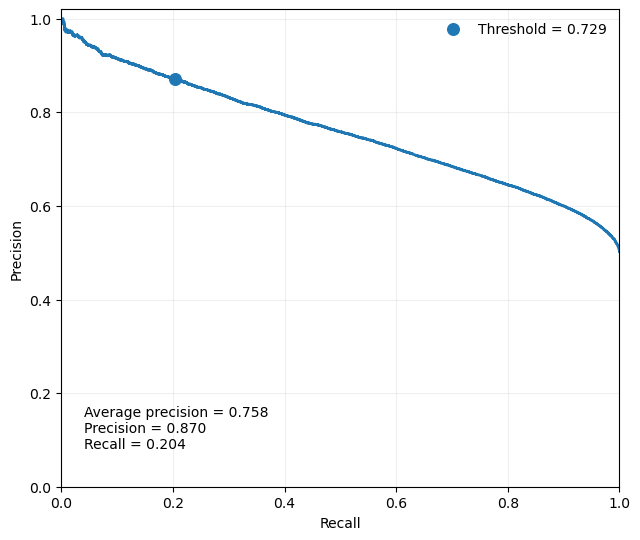

In [5]:
# Precision–recall curve
pr_precision, pr_recall, pr_thresholds = precision_recall_curve(y_test, p_test)
ap = average_precision_score(y_test, p_test)

fig, ax = plt.subplots(figsize=(7.2, 6.2))
ax.plot(pr_recall, pr_precision, linewidth=2)
ax.scatter([recall], [precision], s=70, zorder=3, label=f"Threshold = {FINAL_THRESHOLD:.3f}")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.grid(alpha=0.2)
ax.legend(frameon=False)
ax.text(
    0.04, 0.08,
    f"Average precision = {ap:.3f}\n"
    f"Precision = {precision:.3f}\n"
    f"Recall = {recall:.3f}",
    transform=ax.transAxes,
)
save_figure(fig, FIGURE_DIR / "precision_recall_curve")
plt.show()


In [ ]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(6.5, 6.0))
ConfusionMatrixDisplay(
    confusion_matrix=np.array([[tn, fp], [fn, tp]]),
    display_labels=["Non-continuity", "Continuity"],
).plot(ax=ax, cmap="Blues", colorbar=False, values_format=",d")
ax.set_title(f"Threshold = {FINAL_THRESHOLD:.3f}")
save_figure(fig, FIGURE_DIR / "confusion_matrix")
plt.show()


In [ ]:
# ROC curve
fpr, tpr, _ = roc_curve(y_test, p_test)
roc_auc = roc_auc_score(y_test, p_test)

fig, ax = plt.subplots(figsize=(7.2, 6.2))
ax.plot(fpr, tpr, linewidth=2)
ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
ax.set_xlabel("False-positive rate")
ax.set_ylabel("True-positive rate")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(alpha=0.2)
ax.text(
    0.65, 0.07,
    f"ROC-AUC = {roc_auc:.3f}",
    transform=ax.transAxes,
)
save_figure(fig, FIGURE_DIR / "roc_curve")
plt.show()


Saved: /mnt/eo/EO4Backcasting/_figs/plotting_only_gt0729/calibration_plot.png
Saved: /mnt/eo/EO4Backcasting/_figs/plotting_only_gt0729/calibration_plot.svg


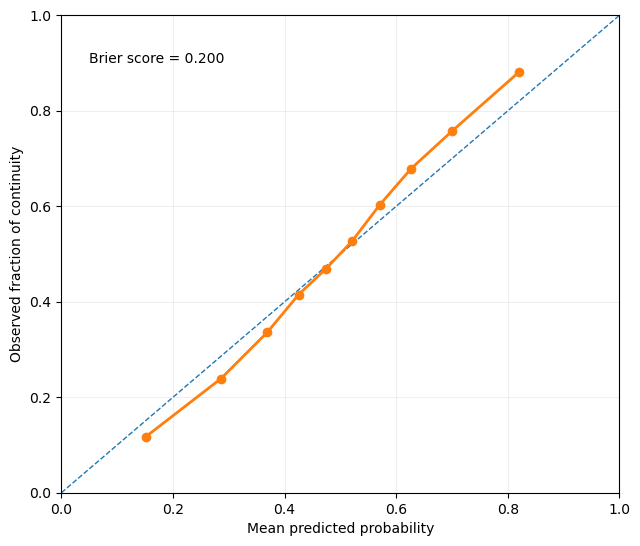

In [6]:
# Calibration plot
prob_true, prob_pred = calibration_curve(
    y_test,
    p_test,
    n_bins=10,
    strategy="quantile",
)
brier = brier_score_loss(y_test, p_test)

fig, ax = plt.subplots(figsize=(7.2, 6.2))
ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
ax.plot(prob_pred, prob_true, marker="o", linewidth=2)
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed fraction of continuity")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(alpha=0.2)
ax.text(
    0.05, 0.90,
    f"Brier score = {brier:.3f}",
    transform=ax.transAxes,
)
save_figure(fig, FIGURE_DIR / "calibration_plot")
plt.show()


## 3. SHAP figures from existing caches

In [7]:
# Load cached SHAP products only
shap_importance = pd.read_csv(
    require_file(SHAP_IMPORTANCE_CSV, "SHAP importance cache")
)

df_shap = pd.read_pickle(
    require_file(SHAP_FULL_PKL, "Full SHAP table cache")
)

print("SHAP rows:", len(df_shap))
print("Importance columns:", list(shap_importance.columns))


SHAP rows: 390987
Importance columns: ['feature', 'mean_abs_shap']


Saved: /mnt/eo/EO4Backcasting/_figs/plotting_only_gt0729/shap_global_importance.png
Saved: /mnt/eo/EO4Backcasting/_figs/plotting_only_gt0729/shap_global_importance.svg


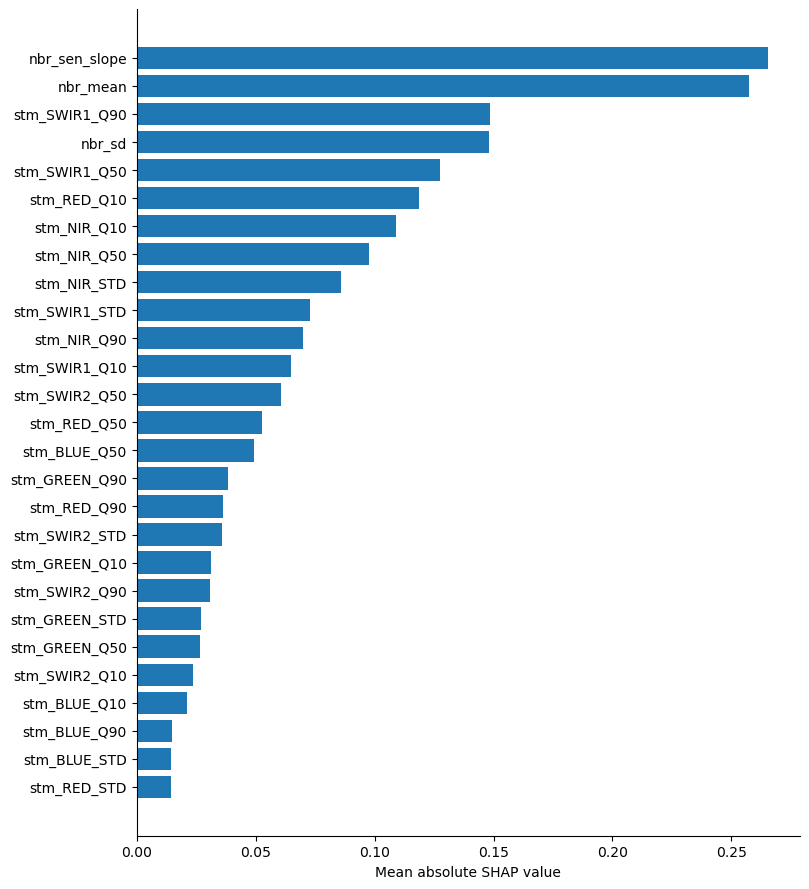

In [8]:
# Global SHAP importance
feature_col = next(
    (c for c in ["feature", "predictor", "Feature"] if c in shap_importance.columns),
    None,
)
importance_col = next(
    (
        c for c in [
            "mean_abs_shap",
            "mean_absolute_shap",
            "importance",
            "Mean |SHAP value|",
        ]
        if c in shap_importance.columns
    ),
    None,
)

if feature_col is None or importance_col is None:
    raise ValueError(
        "Could not identify feature and importance columns. "
        f"Columns: {list(shap_importance.columns)}"
    )

importance_plot = (
    shap_importance
    .sort_values(importance_col, ascending=True)
    .copy()
)

fig, ax = plt.subplots(figsize=(8.2, 9.0))
ax.barh(importance_plot[feature_col], importance_plot[importance_col])
ax.set_xlabel("Mean absolute SHAP value")
ax.set_ylabel("")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
save_figure(fig, FIGURE_DIR / "shap_global_importance")
plt.show()


Saved: /mnt/eo/EO4Backcasting/_figs/plotting_only_gt0729/shap_dependence_top8.png
Saved: /mnt/eo/EO4Backcasting/_figs/plotting_only_gt0729/shap_dependence_top8.svg


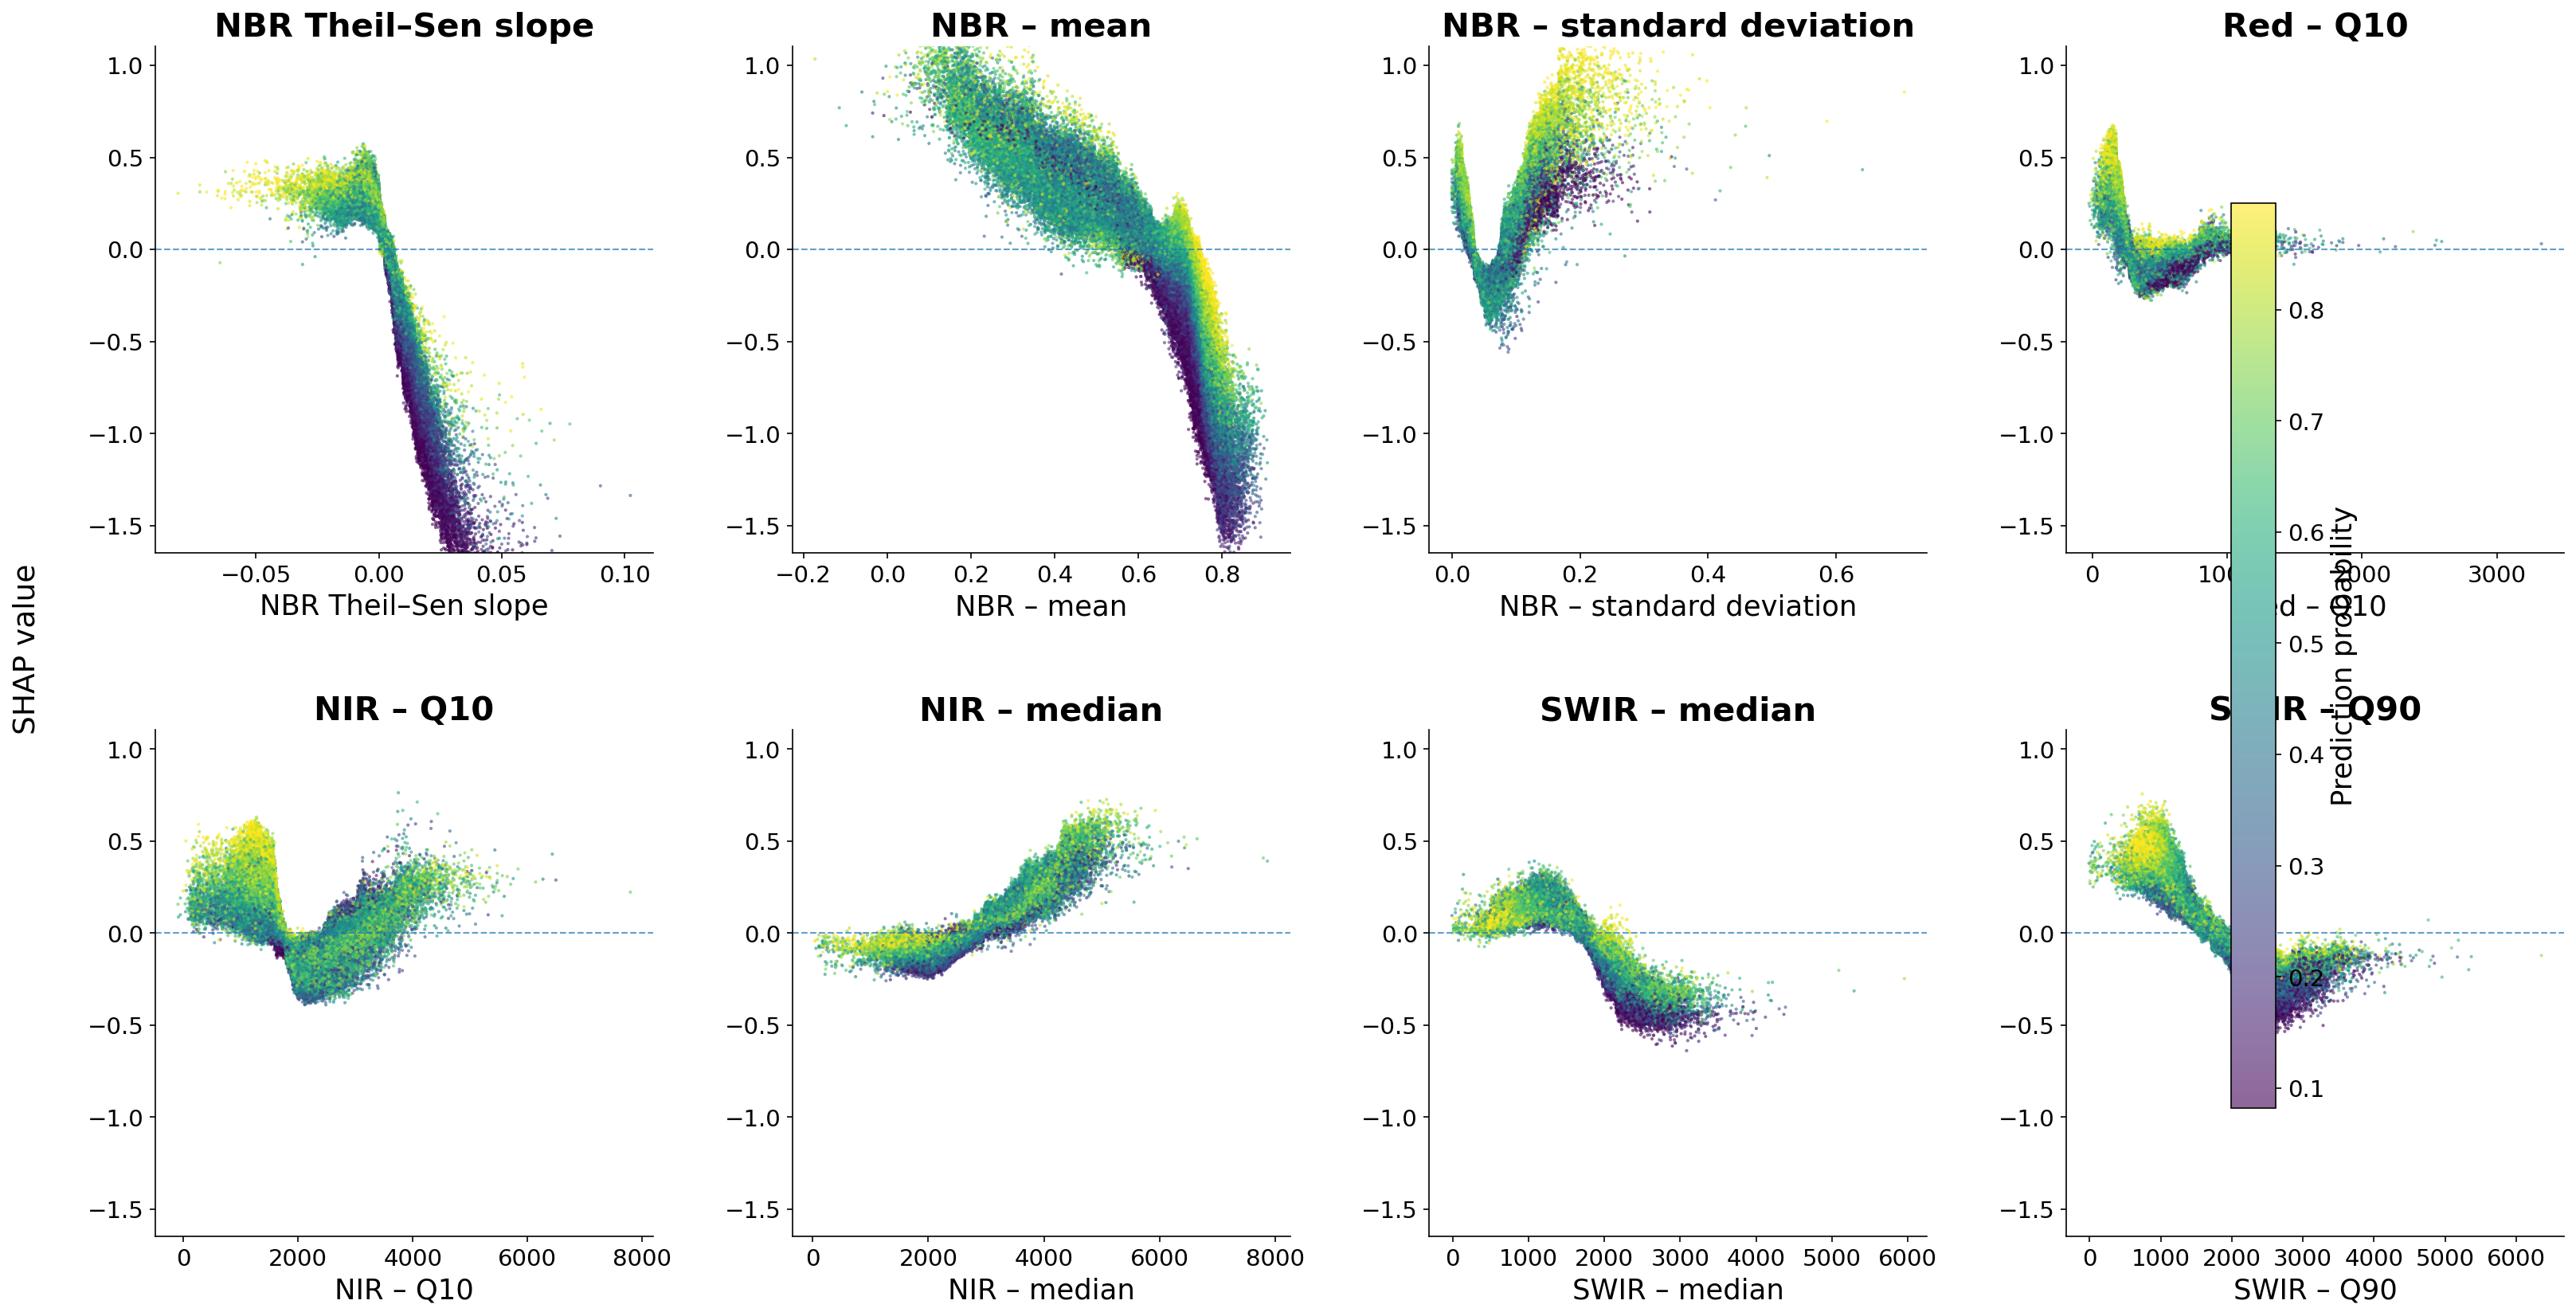

In [9]:
# SHAP dependence plots for the eight selected predictors
top_features = [
    "nbr_sen_slope",
    "nbr_mean",
    "nbr_sd",
    "stm_RED_Q10",
    "stm_NIR_Q10",
    "stm_NIR_Q50",
    "stm_SWIR1_Q50",
    "stm_SWIR1_Q90",
]

feature_labels = {
    "nbr_sen_slope": "NBR Theil–Sen slope",
    "nbr_mean": "NBR – mean",
    "nbr_sd": "NBR – standard deviation",
    "stm_RED_Q10": "Red – Q10",
    "stm_NIR_Q10": "NIR – Q10",
    "stm_NIR_Q50": "NIR – median",
    "stm_SWIR1_Q50": "SWIR – median",
    "stm_SWIR1_Q90": "SWIR – Q90",
}

required = []
for feat in top_features:
    required.extend([feat, f"shap_{feat}"])
required.append("prediction_probability")

missing = [c for c in required if c not in df_shap.columns]
if missing:
    raise ValueError(f"Missing SHAP columns: {missing}")

df_plot = (
    df_shap[required]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

# The cache may already be sampled. This only limits plotting density and
# does not generate new analytical samples.
if len(df_plot) > 150_000:
    df_plot = df_plot.iloc[
        np.linspace(0, len(df_plot) - 1, 150_000, dtype=int)
    ].copy()

shap_cols = [f"shap_{feat}" for feat in top_features]
y_min = df_plot[shap_cols].quantile(0.01).min()
y_max = df_plot[shap_cols].quantile(0.99).max()
y_pad = 0.12 * (y_max - y_min)
y_min -= y_pad
y_max += y_pad

cmin = df_plot["prediction_probability"].quantile(0.01)
cmax = df_plot["prediction_probability"].quantile(0.99)
norm = Normalize(vmin=cmin, vmax=cmax)

fig, axes = plt.subplots(2, 4, figsize=(24, 12), dpi=150)
axes = axes.ravel()

scatter_ref = None
for ax, feat in zip(axes, top_features):
    scatter_ref = ax.scatter(
        df_plot[feat],
        df_plot[f"shap_{feat}"],
        c=df_plot["prediction_probability"],
        cmap="viridis",
        norm=norm,
        s=4,
        alpha=0.6,
        edgecolors="none",
    )
    ax.axhline(0, linestyle="--", linewidth=1, alpha=0.7)
    ax.set_ylim(y_min, y_max)
    ax.set_title(feature_labels[feat], fontsize=20, fontweight="bold")
    ax.set_xlabel(feature_labels[feat], fontsize=17)
    ax.set_ylabel("")
    ax.tick_params(labelsize=14)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.supylabel("SHAP value", fontsize=18, x=0.01)
cbar = fig.colorbar(scatter_ref, ax=axes.tolist(), shrink=0.82, pad=0.02)
cbar.set_label("Prediction probability", fontsize=17)
cbar.ax.tick_params(labelsize=14)
fig.subplots_adjust(left=0.06, right=0.90, bottom=0.09, top=0.92, wspace=0.28, hspace=0.35)

save_figure(fig, FIGURE_DIR / "shap_dependence_top8")
plt.show()


Loading layer 'shap_points_europe' from shap_points_europe.gpkg
Loading layer 'CNTR_RG_10M_2024_3035' from CNTR_RG_10M_2024_3035.gpkg
Saved: /mnt/eo/EO4Backcasting/_figs/plotting_only_gt0729/spatial_dominant_positive_shap_group.png
Saved: /mnt/eo/EO4Backcasting/_figs/plotting_only_gt0729/spatial_dominant_positive_shap_group.svg


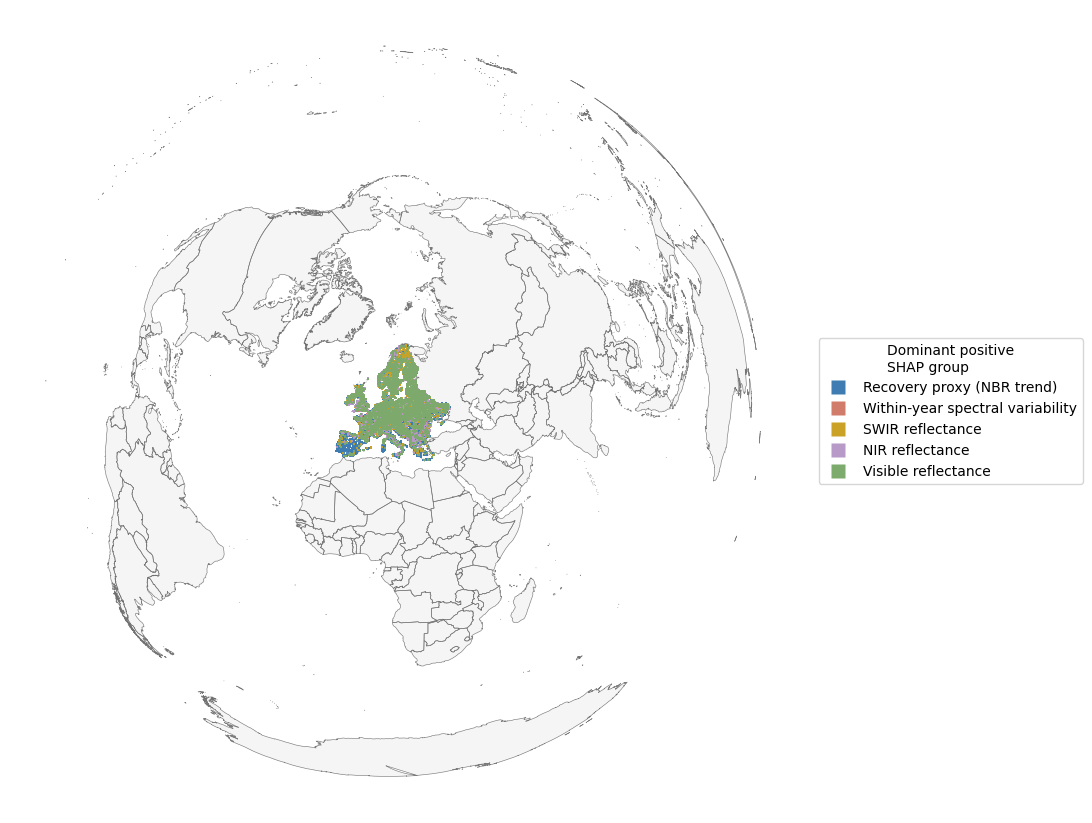

In [10]:
# Spatial dominant-positive-SHAP map from the cached GeoPackage
gdf_shap = read_first_gpkg_layer(SHAP_POINTS_GPKG)

group_rename = {
    "Post-1985 NBR dynamics": "Recovery proxy (NBR trend)",
    "SWIR spectral level": "SWIR reflectance",
    "NIR spectral level": "NIR reflectance",
    "Visible spectral level": "Visible reflectance",
}

group_col = "dominant_positive_shap_group"
if group_col not in gdf_shap.columns:
    raise ValueError(f"Missing column: {group_col}")

gdf_shap[group_col] = gdf_shap[group_col].replace(group_rename)
gdf_high = gdf_shap[
    gdf_shap["prediction_probability"] >= FINAL_THRESHOLD
].copy()
gdf_high = gdf_high[
    gdf_high[group_col] != "No positive contribution"
].copy()

group_colors = {
    "Recovery proxy (NBR trend)": "#3E7CB1",
    "Within-year spectral variability": "#D17C6B",
    "SWIR reflectance": "#C9A227",
    "NIR reflectance": "#B79AC8",
    "Visible reflectance": "#7DAA6D",
    "Other": "#6E6E6E",
}

group_order = [
    g for g in group_colors
    if g in set(gdf_high[group_col].dropna())
]

countries_shap = load_countries(gdf_high.crs)

fig, ax = plt.subplots(figsize=(12, 10.5))
countries_shap.plot(ax=ax, facecolor="#f5f5f5", edgecolor="none", zorder=0)
countries_shap.boundary.plot(
    ax=ax, color="#6f6f6f", linewidth=0.45, alpha=0.9, zorder=1
)

for group in group_order:
    sub = gdf_high[gdf_high[group_col] == group]
    sub.plot(
        ax=ax,
        color=group_colors[group],
        markersize=4,
        alpha=0.90,
        linewidth=0,
        marker="s",
        zorder=2,
    )

handles = [
    Line2D(
        [0], [0], marker="s", color="none",
        markerfacecolor=group_colors[g],
        markeredgecolor="none",
        markersize=10,
        label=g,
    )
    for g in group_order
]

ax.legend(
    handles=handles,
    title="Dominant positive\nSHAP group",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
)
ax.set_axis_off()
ax.set_aspect("equal")
fig.subplots_adjust(right=0.78)

save_figure(fig, FIGURE_DIR / "spatial_dominant_positive_shap_group")
plt.show()


## 4. Forest-continuity hexagon maps from the existing GeoPackage

In [11]:
hexes_plot = read_first_gpkg_layer(HEX_GPKG)

required_hex_cols = [
    "hex_id",
    "forest_area_ha",
    "continuity_area_km2",
    "continuity_share_percent",
]
missing = [c for c in required_hex_cols if c not in hexes_plot.columns]
if missing:
    raise ValueError(
        f"Missing columns in the cached hexagon file: {missing}\n"
        f"Available: {list(hexes_plot.columns)}"
    )

countries_eur = load_countries(hexes_plot.crs)

print("Hexagons:", len(hexes_plot))
display(
    hexes_plot[
        ["forest_area_ha", "continuity_area_km2", "continuity_share_percent"]
    ].describe()
)


Loading layer 'hexes' from forest_continuity_gt0729_by_small_clipped_hexagon_lon45_gt0729.gpkg
Loading layer 'CNTR_RG_10M_2024_3035' from CNTR_RG_10M_2024_3035.gpkg
Hexagons: 7694


,forest_area_ha,continuity_area_km2,continuity_share_percent
count,7694.000000,7694.000000,7694.000000
mean,27920.501811,25.576157,9.166282
std,21003.522128,31.590267,7.381488
min,505.080000,0.000000,0.000000
25%,8850.667500,4.917600,3.735739
50%,24244.965000,13.103100,6.967157
75%,44162.370000,33.861825,12.724593
max,75618.090000,327.147300,63.681193


In [27]:
# ------------------------------------------------------------
# Reload original data
# ------------------------------------------------------------

hexes_plot = read_first_gpkg_layer(HEX_GPKG)
countries_all = load_countries(hexes_plot.crs)

country_name_col = find_country_name_column(countries_all)

print(
    sorted(
        countries_all[country_name_col]
        .dropna()
        .astype(str)
        .unique()
    )
)

Loading layer 'hexes' from forest_continuity_gt0729_by_small_clipped_hexagon_lon45_gt0729.gpkg
Loading layer 'CNTR_RG_10M_2024_3035' from CNTR_RG_10M_2024_3035.gpkg
['Abyei', 'Afghanistan', 'Aksai Chin', 'Albania', 'Algeria', 'American Samoa', 'Andorra', 'Angola', 'Anguilla', 'Antarctica', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Aruba', 'Arunachal Pradesh', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados', 'Bassas Da India', 'Belarus', 'Belgium', 'Belize', 'Belize/Guatemala', 'Benin', 'Bermuda', 'Bhutan', 'Bir Tawil (Disputed Territory)', 'Bolivia', 'Bonaire, Sint Eustatius and Saba', 'Bosnia and Herzegovina', 'Botswana', 'Bouvet Island', 'Brazil', 'British Virgin Islands', 'Brunei', 'Bulgaria', 'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon', 'Canada', 'Cape Verde', 'Cayman Islands', 'Central African Republic', 'Chad', 'Chagos Islands (disputed territory)', 'Chile', 'China', 'China/India', 'Christmas Island', 'Clipperton Island', 'Cocos (K

In [33]:
from pathlib import Path
import geopandas as gpd
from shapely.geometry import box

# ------------------------------------------------------------
# Country input
# ------------------------------------------------------------

country_gpkg = Path(
    "/mnt/eo/EO4Backcasting/_data/"
    "CNTR_RG_10M_2024_3035.gpkg"
)

country_name_col = "NAME_ENGL"

if not country_gpkg.exists():
    raise FileNotFoundError(
        f"Country GeoPackage not found:\n{country_gpkg}"
    )

# ------------------------------------------------------------
# Define European study countries
# ------------------------------------------------------------

european_countries = [
    "Albania", "Andorra", "Austria", "Belarus", "Belgium",
    "Bosnia and Herzegovina", "Bulgaria", "Croatia", "Czechia",
    "Denmark", "Estonia", "Finland", "France", "Germany",
    "Greece", "Hungary", "Ireland", "Italy", "Kosovo", "Latvia",
    "Liechtenstein", "Lithuania", "Luxembourg", "Moldova", "Monaco",
    "Montenegro", "Netherlands", "North Macedonia", "Norway", "Poland",
    "Portugal", "Romania", "San Marino", "Serbia", "Slovakia",
    "Slovenia", "Spain", "Sweden", "Switzerland", "Ukraine",
    "United Kingdom", "Vatican"
]

excluded_countries = {
    "Russian Federation",
    "Russia",
    "Turkey",
    "Kazakhstan",
}

# ------------------------------------------------------------
# Load countries
# ------------------------------------------------------------

countries_all = gpd.read_file(country_gpkg)

countries_all[country_name_col] = (
    countries_all[country_name_col]
    .astype(str)
    .str.strip()
)

countries_eur = countries_all[
    countries_all[country_name_col].isin(european_countries)
    & ~countries_all[country_name_col].isin(excluded_countries)
].copy()

countries_eur = countries_eur[
    countries_eur.geometry.notna()
    & ~countries_eur.geometry.is_empty
].copy()

countries_eur["geometry"] = countries_eur.geometry.make_valid()

# ------------------------------------------------------------
# Remove overseas and remote polygon parts
# ------------------------------------------------------------

countries_eur_4326 = countries_eur.to_crs("EPSG:4326")

countries_parts = (
    countries_eur_4326
    .explode(index_parts=False)
    .reset_index(drop=True)
)

rep_points = countries_parts.representative_point()

keep = (
    (rep_points.x >= -11)
    & (rep_points.x <= 45)
    & (rep_points.y >= 34)
    & (rep_points.y <= 72)
)

countries_parts = countries_parts.loc[keep].copy()

# Dissolve remaining European parts back by country
countries_eur = countries_parts.dissolve(
    by=country_name_col,
    as_index=False
)

# Match the hexagon CRS
countries_eur = countries_eur.to_crs(hexes_plot.crs)

print("Countries retained:", len(countries_eur))
print(
    sorted(
        countries_eur[country_name_col]
        .dropna()
        .unique()
    )
)

Countries retained: 40
['Albania', 'Andorra', 'Austria', 'Belarus', 'Belgium', 'Bosnia and Herzegovina', 'Bulgaria', 'Croatia', 'Czechia', 'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Ireland', 'Italy', 'Latvia', 'Liechtenstein', 'Lithuania', 'Luxembourg', 'Moldova', 'Monaco', 'Montenegro', 'Netherlands', 'North Macedonia', 'Norway', 'Poland', 'Portugal', 'Romania', 'San Marino', 'Serbia', 'Slovakia', 'Slovenia', 'Spain', 'Sweden', 'Switzerland', 'Ukraine', 'United Kingdom']


In [34]:
study_area = countries_eur.geometry.union_all()

hexes_plot = hexes_plot[
    hexes_plot.geometry.intersects(study_area)
].copy()

hexes_plot = gpd.clip(
    hexes_plot,
    study_area
).copy()

hexes_plot = hexes_plot[
    hexes_plot.geometry.notna()
    & ~hexes_plot.geometry.is_empty
].copy()

print("Hexagons retained:", len(hexes_plot))

Hexagons retained: 7694


Saved: /mnt/eo/EO4Backcasting/_figs/plotting_only_gt0729/forest_continuity_share_hexagons.png
Saved: /mnt/eo/EO4Backcasting/_figs/plotting_only_gt0729/forest_continuity_share_hexagons.svg


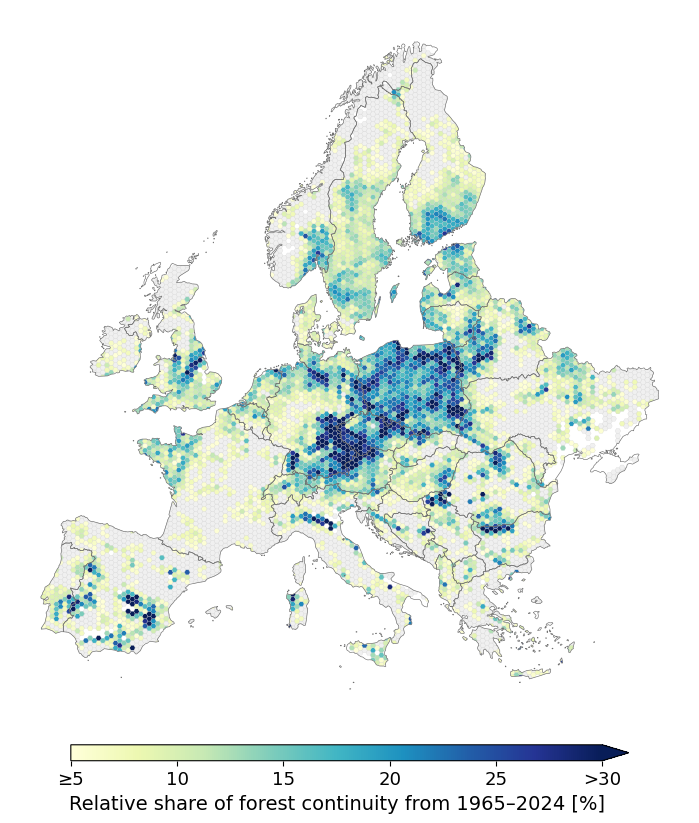

In [35]:
# Relative continuity share:
# <5% grey, 5–30% continuous colours, >30% darkest colour
rel_col = "continuity_share_percent"
low_threshold = 5
upper_threshold = 30

hexes_rel = hexes_plot[hexes_plot[rel_col].notna()].copy()
hexes_low = hexes_rel[hexes_rel[rel_col] < low_threshold].copy()
hexes_high = hexes_rel[hexes_rel[rel_col] >= low_threshold].copy()

norm = mpl.colors.Normalize(
    vmin=low_threshold,
    vmax=upper_threshold,
    clip=False,
)
cmap = plt.get_cmap("YlGnBu").copy()
cmap.set_over(cmap(1.0))

fig, ax = plt.subplots(figsize=(10, 10))

if len(hexes_low):
    hexes_low.plot(
        ax=ax,
        color="0.94",
        linewidth=0.18,
        edgecolor="0.82",
        zorder=1,
    )

if len(hexes_high):
    hexes_high.plot(
        column=rel_col,
        ax=ax,
        cmap=cmap,
        norm=norm,
        linewidth=0.18,
        edgecolor="0.82",
        zorder=2,
    )

countries_eur.boundary.plot(
    ax=ax,
    color="#6f6f6f",
    linewidth=0.45,
    zorder=3,
)

sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax,
    orientation="horizontal",
    shrink=0.72,
    pad=0.03,
    fraction=0.045,
    aspect=35,
    ticks=[5, 10, 15, 20, 25, 30],
    extend="max",
)
cbar.ax.set_xticklabels(["≥5", "10", "15", "20", "25", ">30"])
cbar.set_label(
    "Relative share of forest continuity from 1965–2024 [%]",
    fontsize=14,
)
cbar.ax.tick_params(labelsize=13)

ax.set_axis_off()
ax.set_aspect("equal")

save_figure(fig, FIGURE_DIR / "forest_continuity_share_hexagons")
plt.show()


Saved: /mnt/eo/EO4Backcasting/_figs/plotting_only_gt0729/forest_continuity_area_hexagons.png
Saved: /mnt/eo/EO4Backcasting/_figs/plotting_only_gt0729/forest_continuity_area_hexagons.svg


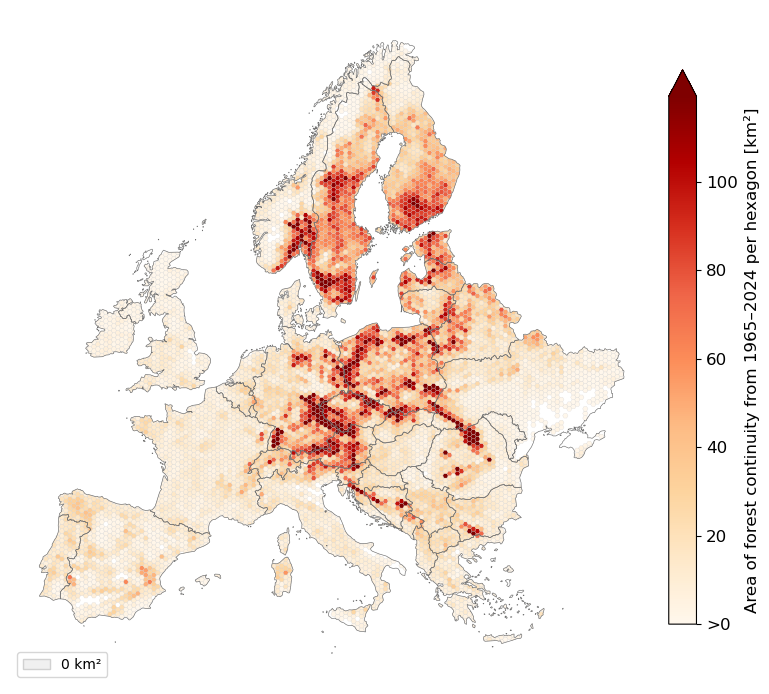

In [36]:
# Absolute continuity area per hexagon, capped at the 98th percentile
abs_col = "continuity_area_km2"

hexes_abs = hexes_plot[hexes_plot[abs_col].notna()].copy()
hexes_zero = hexes_abs[hexes_abs[abs_col] <= 0].copy()
hexes_positive = hexes_abs[hexes_abs[abs_col] > 0].copy()

if hexes_positive.empty:
    raise ValueError("No positive continuity areas found.")

vmax_abs = float(np.nanpercentile(hexes_positive[abs_col], 98))
norm_abs = mpl.colors.Normalize(vmin=0, vmax=vmax_abs, clip=False)
cmap_abs = plt.get_cmap("OrRd").copy()
cmap_abs.set_over(cmap_abs(1.0))

fig, ax = plt.subplots(figsize=(10, 10))

if len(hexes_zero):
    hexes_zero.plot(
        ax=ax,
        color="0.94",
        linewidth=0.18,
        edgecolor="0.82",
        zorder=1,
    )

hexes_positive.plot(
    column=abs_col,
    ax=ax,
    cmap=cmap_abs,
    norm=norm_abs,
    linewidth=0.18,
    edgecolor="0.82",
    zorder=2,
)

countries_eur.boundary.plot(
    ax=ax,
    color="#6f6f6f",
    linewidth=0.45,
    zorder=3,
)

sm_abs = ScalarMappable(cmap=cmap_abs, norm=norm_abs)
sm_abs.set_array([])

cbar = fig.colorbar(
    sm_abs,
    ax=ax,
    shrink=0.72,
    pad=0.02,
    extend="max",
)
cbar.ax.yaxis.set_major_formatter(
    mpl.ticker.FuncFormatter(
        lambda x, pos: ">0" if np.isclose(x, 0) else f"{x:g}"
    )
)
cbar.set_label(
    "Area of forest continuity from 1965–2024 per hexagon [km²]",
    fontsize=12,
)
cbar.ax.tick_params(labelsize=12)

ax.legend(
    handles=[
        Patch(facecolor="0.94", edgecolor="0.82", label="0 km²")
    ],
    loc="lower left",
    frameon=True,
)
ax.set_axis_off()
ax.set_aspect("equal")

save_figure(fig, FIGURE_DIR / "forest_continuity_area_hexagons")
plt.show()


## 5. Country and genus summaries from cached CSV files

In [37]:
country_share = pd.read_csv(
    require_file(COUNTRY_SHARE_CSV, "Country continuity-share cache")
)

print("Country-share columns:", list(country_share.columns))
display(country_share.head())


Country-share columns: ['country', 'forest_pixels', 'continuity_pixels', 'forest_area_ha', 'continuity_area_ha', 'relative_continuity_share_percent']


,country,forest_pixels,continuity_pixels,forest_area_ha,continuity_area_ha,relative_continuity_share_percent
0,Albania,10171746,730029,915457.14,65702.61,7.177027
1,Andorra,214217,7167,19279.53,645.03,3.345673
2,Armenia,0,0,0.00,0.00,NaN
3,Austria,49986108,7913637,4498749.72,712227.33,15.831673
4,Azerbaijan,0,0,0.00,0.00,NaN


Loaded: /mnt/eo/EO4Backcasting/_analysis_cache/continuously_undisturbed_share_by_country_gt0729.csv
Columns: ['country', 'forest_pixels', 'continuity_pixels', 'forest_area_ha', 'continuity_area_ha', 'relative_continuity_share_percent']
Rows: 54
Country column: country
Share column: relative_continuity_share_percent


,country,relative_continuity_share_percent
0,Belarus,10.073318
1,Switzerland,10.940180
2,Latvia,12.072716
3,Lithuania,13.412866
4,Estonia,13.985418
5,Austria,15.831673
6,Liechtenstein,16.073122
7,Germany,16.540947
8,Poland,22.154330
9,Czechia,22.832429


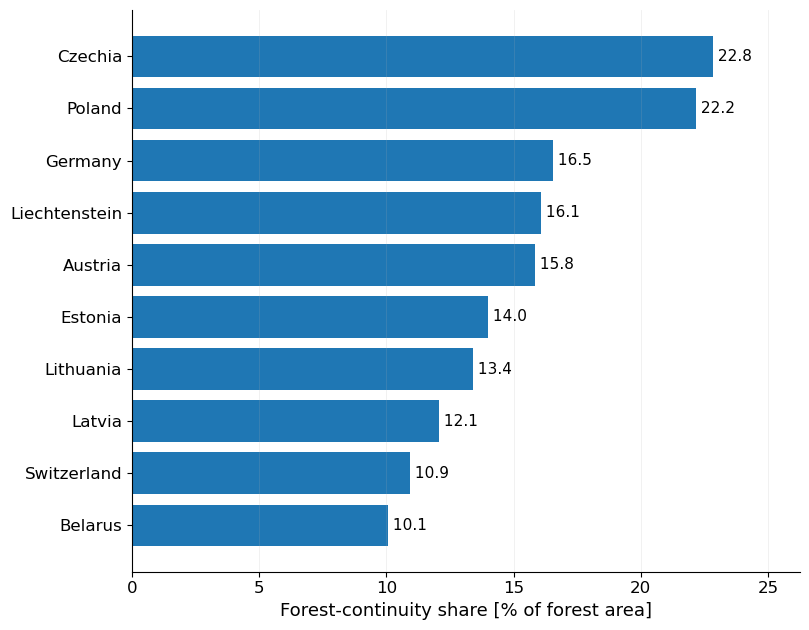

Saved PNG: /mnt/eo/EO4Backcasting/_figs/plotting_only_gt0729/country_continuity_share_top10.png
Saved SVG: /mnt/eo/EO4Backcasting/_figs/plotting_only_gt0729/country_continuity_share_top10.svg


In [39]:
# ============================================================
# Top 10 countries by relative forest continuity share
# Loads the cached country table and creates a horizontal bar plot
# ============================================================

from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

BASE_DIR = Path("/mnt/eo/EO4Backcasting")
CACHE_DIR = BASE_DIR / "_analysis_cache"
FIGURE_DIR = BASE_DIR / "_figs" / "plotting_only_gt0729"

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

COUNTRY_SHARE_CSV = (
    CACHE_DIR
    / "continuously_undisturbed_share_by_country_gt0729.csv"
)

# ------------------------------------------------------------
# Load cached country statistics
# ------------------------------------------------------------

if not COUNTRY_SHARE_CSV.exists():
    raise FileNotFoundError(
        "Country continuity-share cache was not found:\n"
        f"{COUNTRY_SHARE_CSV}"
    )

country_share = pd.read_csv(
    COUNTRY_SHARE_CSV
)

print("Loaded:", COUNTRY_SHARE_CSV)
print("Columns:", list(country_share.columns))
print("Rows:", len(country_share))

# ------------------------------------------------------------
# Detect relevant columns
# ------------------------------------------------------------

country_col = next(
    (
        col
        for col in [
            "country",
            "NAME_ENGL",
            "country_name",
        ]
        if col in country_share.columns
    ),
    None,
)

share_col = next(
    (
        col
        for col in [
            "relative_continuity_share_percent",
            "continuity_share_percent",
            "oldgrowth_share_percent",
            "continuously_undisturbed_share_percent",
        ]
        if col in country_share.columns
    ),
    None,
)

if country_col is None:
    raise ValueError(
        "Could not identify the country-name column.\n"
        f"Available columns: {list(country_share.columns)}"
    )

if share_col is None:
    raise ValueError(
        "Could not identify the continuity-share column.\n"
        f"Available columns: {list(country_share.columns)}"
    )

print("Country column:", country_col)
print("Share column:", share_col)

# ------------------------------------------------------------
# Clean values
# ------------------------------------------------------------

country_share[country_col] = (
    country_share[country_col]
    .astype(str)
    .str.strip()
)

country_share[share_col] = pd.to_numeric(
    country_share[share_col],
    errors="coerce"
)

country_share_clean = (
    country_share
    .replace(
        [float("inf"), float("-inf")],
        pd.NA
    )
    .dropna(
        subset=[
            country_col,
            share_col,
        ]
    )
    .copy()
)

if country_share_clean.empty:
    raise ValueError(
        "No valid country continuity-share values found."
    )

# ------------------------------------------------------------
# Select top 10
# ------------------------------------------------------------

top10 = (
    country_share_clean
    .nlargest(
        10,
        share_col
    )
    .sort_values(
        share_col,
        ascending=True
    )
    .reset_index(
        drop=True
    )
)

display(
    top10[
        [
            country_col,
            share_col,
        ]
    ]
)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(8.2, 6.4)
)

bars = ax.barh(
    top10[country_col],
    top10[share_col]
)

ax.set_xlabel(
    "Forest-continuity share [% of forest area]",
    fontsize=13
)

ax.set_ylabel("")

ax.tick_params(
    axis="both",
    labelsize=12
)

# Add values at the ends of the bars
for bar, value in zip(
    bars,
    top10[share_col]
):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {value:.1f}",
        va="center",
        ha="left",
        fontsize=11
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="x",
    linewidth=0.6,
    alpha=0.20
)

# Leave enough space for labels at the bar ends
xmax = float(top10[share_col].max())

if xmax > 0:
    ax.set_xlim(
        0,
        xmax * 1.15
    )

plt.tight_layout()

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

out_png = (
    FIGURE_DIR
    / "country_continuity_share_top10.png"
)

out_svg = (
    FIGURE_DIR
    / "country_continuity_share_top10.svg"
)

fig.savefig(
    out_png,
    dpi=400,
    bbox_inches="tight",
    facecolor="white"
)

fig.savefig(
    out_svg,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Saved PNG:", out_png)
print("Saved SVG:", out_svg)

In [40]:
# Load country × genus counts. Ratios below are lightweight derived
# columns from the cached table; no raster is read.
country_genus_counts = pd.read_csv(
    require_file(COUNTRY_GENUS_COUNTS_CSV, "Country × genus counts cache")
)

required = ["country", "genus", "total_pixels", "continuity_pixels"]
missing = [c for c in required if c not in country_genus_counts.columns]
if missing:
    raise ValueError(
        f"Missing columns in country-genus cache: {missing}\n"
        f"Available: {list(country_genus_counts.columns)}"
    )

country_genus_oe = country_genus_counts.copy()
grouped = country_genus_oe.groupby("country")

country_genus_oe["country_total_pixels"] = grouped[
    "total_pixels"
].transform("sum")
country_genus_oe["country_continuity_pixels"] = grouped[
    "continuity_pixels"
].transform("sum")

country_genus_oe["share_in_all_forests"] = (
    country_genus_oe["total_pixels"]
    / country_genus_oe["country_total_pixels"]
)
country_genus_oe["share_in_continuity_forests"] = (
    country_genus_oe["continuity_pixels"]
    / country_genus_oe["country_continuity_pixels"]
)

country_genus_oe["observed_expected_ratio"] = (
    country_genus_oe["share_in_continuity_forests"]
    / country_genus_oe["share_in_all_forests"]
)

pseudocount = 0.5
n_genera = country_genus_oe["genus"].nunique()

country_genus_oe["ratio_smoothed"] = (
    (
        (country_genus_oe["continuity_pixels"] + pseudocount)
        / (
            country_genus_oe["country_continuity_pixels"]
            + pseudocount * n_genera
        )
    )
    /
    (
        (country_genus_oe["total_pixels"] + pseudocount)
        / (
            country_genus_oe["country_total_pixels"]
            + pseudocount * n_genera
        )
    )
)
country_genus_oe["log2_ratio_smoothed"] = np.log2(
    country_genus_oe["ratio_smoothed"]
)

display(country_genus_oe.head())


,country,genus,genus_code,total_pixels,continuity_pixels,country_total_pixels,country_continuity_pixels,share_in_all_forests,share_in_continuity_forests,observed_expected_ratio,ratio_smoothed,log2_ratio_smoothed
0,Albania,Larix,0,34152,897,11988503,385608,0.002849,0.002326,0.816573,0.817009,-0.291575
1,Albania,Picea,1,454554,16310,11988503,385608,0.037916,0.042297,1.115546,1.115569,0.157780
2,Albania,Pinus,2,1071886,40610,11988503,385608,0.089409,0.105314,1.177886,1.177890,0.236205
3,Albania,Fagus,3,3552764,147460,11988503,385608,0.296348,0.382409,1.290407,1.290400,0.367818
4,Albania,Quercus,4,2617599,62602,11988503,385608,0.218342,0.162346,0.743539,0.743539,-0.427520


,genus,total_pixels,continuity_pixels,share_all,share_continuity,observed_expected_ratio,log2_observed_expected_ratio
0,Quercus,319807327,7081028,0.196916,0.050776,0.257858,-1.955351
1,Fagus,202383323,6581396,0.124614,0.047194,0.378718,-1.400803
2,Larix,13366166,752832,0.008230,0.005398,0.655940,-0.608364
3,Pinus,627975739,54094362,0.386666,0.387899,1.003187,0.004591
4,Picea,460543753,70945216,0.283573,0.508733,1.794011,0.843189


Saved: /mnt/eo/EO4Backcasting/_figs/plotting_only_gt0729/europe_forest_continuity_share_by_genus_log2_greytone_selected.png
Saved: /mnt/eo/EO4Backcasting/_figs/plotting_only_gt0729/europe_forest_continuity_share_by_genus_log2_greytone_selected.svg


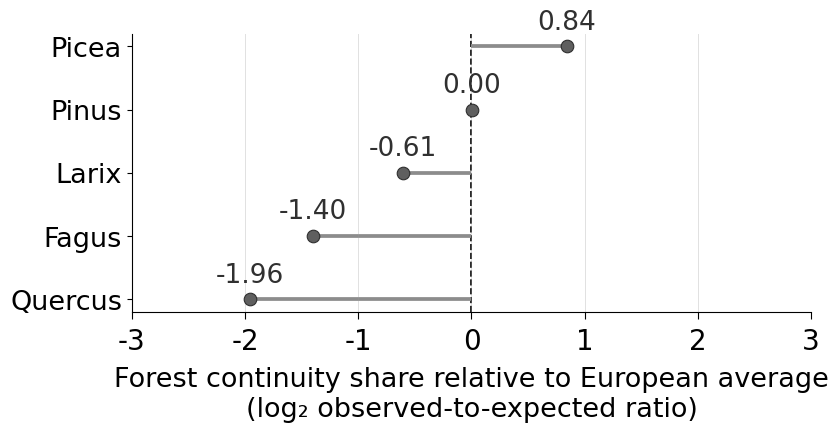

In [61]:
# ============================================================
# Europe-wide genus lollipop plot
# Same metric transformation as in the country maps:
# log2 observed-to-expected ratio
#
# Interpretation:
#   0  = representation as expected
#  -1  = half as frequent as expected
#  +1  = twice as frequent as expected
#  +2  = four times as frequent as expected
#
# Grey tones only
# Without "Other needleleaf" and "Other broadleaf"
# ============================================================

# ------------------------------------------------------------
# Keep only the five focal genera
# ------------------------------------------------------------

genus_order = [
    "Picea",
    "Larix",
    "Pinus",
    "Fagus",
    "Quercus",
]

# ------------------------------------------------------------
# Grey styling
# ------------------------------------------------------------

LOLLIPOP_LINE_COLOR = "#8c8c8c"
LOLLIPOP_MARKER_COLOR = "#5f5f5f"
LOLLIPOP_EDGE_COLOR = "#2f2f2f"
GRID_COLOR = "#9a9a9a"
TEXT_COLOR = "#303030"

# ------------------------------------------------------------
# Aggregate counts across countries
# ------------------------------------------------------------

europe_counts = (
    country_genus_counts
    .groupby(
        "genus",
        as_index=False,
    )[[
        "total_pixels",
        "continuity_pixels",
    ]]
    .sum()
)

# Keep only selected genera
europe_counts = europe_counts[
    europe_counts["genus"].isin(genus_order)
].copy()

if europe_counts.empty:
    raise ValueError(
        "No records found for the selected genera."
    )

# ------------------------------------------------------------
# Calculate Europe-wide observed-to-expected ratios
# ------------------------------------------------------------

total_all = europe_counts["total_pixels"].sum()
total_continuity = europe_counts["continuity_pixels"].sum()

if total_all <= 0:
    raise ValueError(
        "The total number of forest pixels is zero."
    )

if total_continuity <= 0:
    raise ValueError(
        "The total number of continuity pixels is zero."
    )

europe_counts["share_all"] = (
    europe_counts["total_pixels"]
    / total_all
)

europe_counts["share_continuity"] = (
    europe_counts["continuity_pixels"]
    / total_continuity
)

europe_counts["observed_expected_ratio"] = (
    europe_counts["share_continuity"]
    / europe_counts["share_all"]
)

# Remove invalid or non-positive ratios before log transformation
europe_counts = europe_counts[
    europe_counts["observed_expected_ratio"].notna()
    & np.isfinite(europe_counts["observed_expected_ratio"])
    & (europe_counts["observed_expected_ratio"] > 0)
].copy()

# Same transformation as in the maps
europe_counts["log2_observed_expected_ratio"] = np.log2(
    europe_counts["observed_expected_ratio"]
)

# Sort by transformed ratio
europe_plot = (
    europe_counts
    .sort_values(
        "log2_observed_expected_ratio",
        ascending=True,
    )
    .reset_index(drop=True)
)

if europe_plot.empty:
    raise ValueError(
        "No valid positive genus ratios available for plotting."
    )

display(
    europe_plot[
        [
            "genus",
            "total_pixels",
            "continuity_pixels",
            "share_all",
            "share_continuity",
            "observed_expected_ratio",
            "log2_observed_expected_ratio",
        ]
    ]
)

# ------------------------------------------------------------
# Plot positions
# ------------------------------------------------------------

y = np.arange(
    len(europe_plot)
)

fig, ax = plt.subplots(
    figsize=(8.4, 4.4)
)

# ------------------------------------------------------------
# Lollipop plot
# ------------------------------------------------------------

for y_pos, (_, row) in zip(
    y,
    europe_plot.iterrows(),
):
    log2_ratio = float(
        row["log2_observed_expected_ratio"]
    )

    ax.hlines(
        y=y_pos,
        xmin=min(0, log2_ratio),
        xmax=max(0, log2_ratio),
        color=LOLLIPOP_LINE_COLOR,
        linewidth=2.7,
        zorder=1,
    )

    ax.scatter(
        log2_ratio,
        y_pos,
        s=82,
        color=LOLLIPOP_MARKER_COLOR,
        edgecolor=LOLLIPOP_EDGE_COLOR,
        linewidth=0.8,
        zorder=3,
    )

    ax.annotate(
        f"{log2_ratio:.2f}",
        xy=(log2_ratio, y_pos),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=19,
        color=TEXT_COLOR,
        clip_on=False,
    )

# ------------------------------------------------------------
# Reference line: representation as expected
# ------------------------------------------------------------

ax.axvline(
    0,
    color="black",
    linewidth=1.2,
    linestyle="--",
    zorder=0,
)

# ------------------------------------------------------------
# Linear x-axis in log2-ratio space
# ------------------------------------------------------------

log2_min = float(
    europe_plot["log2_observed_expected_ratio"].min()
)

log2_max = float(
    europe_plot["log2_observed_expected_ratio"].max()
)

# Symmetric range around zero for easier comparison
axis_limit = max(
    abs(log2_min),
    abs(log2_max),
)

# Round upward to the next 0.5 step and add some padding
axis_limit = np.ceil(
    axis_limit * 2
) / 2

axis_limit = max(
    axis_limit,
    1.0,
)

axis_limit += 0.25

ax.set_xlim(
    -axis_limit,
    axis_limit,
)

# ------------------------------------------------------------
# X-axis ticks
# ------------------------------------------------------------

tick_min = int(
    np.floor(-axis_limit)
)

tick_max = int(
    np.ceil(axis_limit)
)

x_ticks = np.arange(
    tick_min,
    tick_max + 1,
    1,
)

ax.set_xticks(
    x_ticks
)

ax.set_xticklabels(
    [
        f"{tick:g}"
        for tick in x_ticks
    ],
    fontsize=24,
)

ax.tick_params(
    axis="x",
    which="major",
    labelsize=20,
    length=5,
    pad=6,
)

# ------------------------------------------------------------
# Labels and styling
# ------------------------------------------------------------

ax.set_yticks(y)

ax.set_yticklabels(
    europe_plot["genus"],
    fontsize=19.5,
)

ax.set_xlabel(
    "Forest continuity share relative to European average\n"
    "(log₂ observed-to-expected ratio)",
    fontsize=19.5,
    labelpad=8,
)

ax.set_ylabel("")

ax.grid(
    axis="x",
    which="major",
    linewidth=0.7,
    alpha=0.30,
    color=GRID_COLOR,
)


ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

save_figure(
    fig,
    FIGURE_DIR
    / "europe_forest_continuity_share_by_genus_log2_greytone_selected"
)

plt.show()

,genus,total_pixels,continuity_pixels,share_all,share_continuity,observed_expected_ratio,log2_observed_expected_ratio
0,Quercus,319807327,7081028,0.196916,0.050776,0.257858,-1.955351
1,Fagus,202383323,6581396,0.124614,0.047194,0.378718,-1.400803
2,Larix,13366166,752832,0.008230,0.005398,0.655940,-0.608364
3,Pinus,627975739,54094362,0.386666,0.387899,1.003187,0.004591
4,Picea,460543753,70945216,0.283573,0.508733,1.794011,0.843189


Saved: /mnt/eo/EO4Backcasting/_figs/plotting_only_gt0729/europe_forest_continuity_share_by_genus_log2_coloured_selected.png
Saved: /mnt/eo/EO4Backcasting/_figs/plotting_only_gt0729/europe_forest_continuity_share_by_genus_log2_coloured_selected.svg


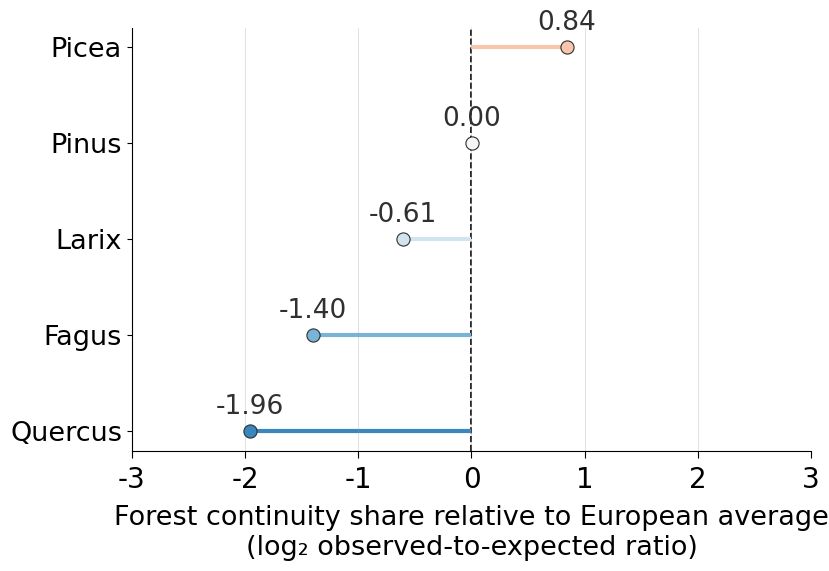

In [69]:
# ============================================================
# Europe-wide genus lollipop plot
# Same metric transformation and colour scale as in the country maps:
# log2 observed-to-expected ratio
#
# Interpretation:
#   0  = representation as expected
#  -1  = half as frequent as expected
#  +1  = twice as frequent as expected
#  +2  = four times as frequent as expected
#
# Colours match the map panels:
# blue = underrepresented
# white = as expected
# red = overrepresented
#
# Without "Other needleleaf" and "Other broadleaf"
# ============================================================

# ------------------------------------------------------------
# Keep only the five focal genera
# ------------------------------------------------------------

genus_order = [
    "Picea",
    "Larix",
    "Pinus",
    "Fagus",
    "Quercus",
]

# ------------------------------------------------------------
# Styling
# ------------------------------------------------------------

LOLLIPOP_EDGE_COLOR = "#2f2f2f"
GRID_COLOR = "#9a9a9a"
TEXT_COLOR = "#303030"

# Same colour scale as in the country maps
cmap = plt.get_cmap("RdBu_r")

norm = TwoSlopeNorm(
    vmin=-3,
    vcenter=0,
    vmax=3,
)

# ------------------------------------------------------------
# Aggregate counts across countries
# ------------------------------------------------------------

europe_counts = (
    country_genus_counts
    .groupby(
        "genus",
        as_index=False,
    )[[
        "total_pixels",
        "continuity_pixels",
    ]]
    .sum()
)

# Keep only selected genera
europe_counts = europe_counts[
    europe_counts["genus"].isin(genus_order)
].copy()

if europe_counts.empty:
    raise ValueError(
        "No records found for the selected genera."
    )

# ------------------------------------------------------------
# Calculate Europe-wide observed-to-expected ratios
# ------------------------------------------------------------

total_all = europe_counts["total_pixels"].sum()
total_continuity = europe_counts["continuity_pixels"].sum()

if total_all <= 0:
    raise ValueError(
        "The total number of forest pixels is zero."
    )

if total_continuity <= 0:
    raise ValueError(
        "The total number of continuity pixels is zero."
    )

europe_counts["share_all"] = (
    europe_counts["total_pixels"]
    / total_all
)

europe_counts["share_continuity"] = (
    europe_counts["continuity_pixels"]
    / total_continuity
)

europe_counts["observed_expected_ratio"] = (
    europe_counts["share_continuity"]
    / europe_counts["share_all"]
)

# Remove invalid or non-positive ratios before log transformation
europe_counts = europe_counts[
    europe_counts["observed_expected_ratio"].notna()
    & np.isfinite(europe_counts["observed_expected_ratio"])
    & (europe_counts["observed_expected_ratio"] > 0)
].copy()

# Same transformation as in the maps
europe_counts["log2_observed_expected_ratio"] = np.log2(
    europe_counts["observed_expected_ratio"]
)

# Sort by transformed ratio
europe_plot = (
    europe_counts
    .sort_values(
        "log2_observed_expected_ratio",
        ascending=True,
    )
    .reset_index(drop=True)
)

if europe_plot.empty:
    raise ValueError(
        "No valid positive genus ratios available for plotting."
    )

display(
    europe_plot[
        [
            "genus",
            "total_pixels",
            "continuity_pixels",
            "share_all",
            "share_continuity",
            "observed_expected_ratio",
            "log2_observed_expected_ratio",
        ]
    ]
)

# ------------------------------------------------------------
# Plot positions
# ------------------------------------------------------------

y = np.arange(
    len(europe_plot)
)

fig, ax = plt.subplots(
    figsize=(8.4, 5.8)
)

# ------------------------------------------------------------
# Lollipop plot
# ------------------------------------------------------------

for y_pos, (_, row) in zip(
    y,
    europe_plot.iterrows(),
):
    log2_ratio = float(
        row["log2_observed_expected_ratio"]
    )

    # Same colour mapping as in the country maps
    point_color = cmap(
        norm(log2_ratio)
    )

    ax.hlines(
        y=y_pos,
        xmin=min(0, log2_ratio),
        xmax=max(0, log2_ratio),
        color=point_color,
        linewidth=3.0,
        zorder=1,
    )

    ax.scatter(
        log2_ratio,
        y_pos,
        s=90,
        color=point_color,
        edgecolor=LOLLIPOP_EDGE_COLOR,
        linewidth=0.8,
        zorder=3,
    )

    ax.annotate(
        f"{log2_ratio:.2f}",
        xy=(log2_ratio, y_pos),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=19,
        color=TEXT_COLOR,
        clip_on=False,
    )

# ------------------------------------------------------------
# Reference line: representation as expected
# ------------------------------------------------------------

ax.axvline(
    0,
    color="black",
    linewidth=1.2,
    linestyle="--",
    zorder=0,
)

# ------------------------------------------------------------
# Linear x-axis in log2-ratio space
# ------------------------------------------------------------

log2_min = float(
    europe_plot["log2_observed_expected_ratio"].min()
)

log2_max = float(
    europe_plot["log2_observed_expected_ratio"].max()
)

# Symmetric range around zero for easier comparison
axis_limit = max(
    abs(log2_min),
    abs(log2_max),
)

# Round upward to the next 0.5 step and add some padding
axis_limit = np.ceil(
    axis_limit * 2
) / 2

axis_limit = max(
    axis_limit,
    1.0,
)

axis_limit += 0.25

ax.set_xlim(
    -axis_limit,
    axis_limit,
)

# ------------------------------------------------------------
# X-axis ticks
# ------------------------------------------------------------

tick_min = int(
    np.floor(-axis_limit)
)

tick_max = int(
    np.ceil(axis_limit)
)

x_ticks = np.arange(
    tick_min,
    tick_max + 1,
    1,
)

ax.set_xticks(
    x_ticks
)

ax.set_xticklabels(
    [
        f"{tick:g}"
        for tick in x_ticks
    ],
    fontsize=24,
)

ax.tick_params(
    axis="x",
    which="major",
    labelsize=20,
    length=5,
    pad=6,
)

# ------------------------------------------------------------
# Labels and styling
# ------------------------------------------------------------

ax.set_yticks(y)

ax.set_yticklabels(
    europe_plot["genus"],
    fontsize=19.5,
)

ax.set_xlabel(
    "Forest continuity share relative to European average\n"
    "(log₂ observed-to-expected ratio)",
    fontsize=19.5,
    labelpad=8,
)

ax.set_ylabel("")

ax.grid(
    axis="x",
    which="major",
    linewidth=0.7,
    alpha=0.30,
    color=GRID_COLOR,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

save_figure(
    fig,
    FIGURE_DIR
    / "europe_forest_continuity_share_by_genus_log2_coloured_selected"
)

plt.show()

Loading layer 'hexes' from forest_continuity_gt0729_by_small_clipped_hexagon_lon45_gt0729.gpkg
Loading layer 'CNTR_RG_10M_2024_3035' from CNTR_RG_10M_2024_3035.gpkg
Selected countries found: ['Albania', 'Andorra', 'Austria', 'Belarus', 'Belgium', 'Bosnia and Herzegovina', 'Bulgaria', 'Croatia', 'Czechia', 'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Ireland', 'Italy', 'Latvia', 'Liechtenstein', 'Lithuania', 'Luxembourg', 'Moldova', 'Monaco', 'Montenegro', 'Netherlands', 'North Macedonia', 'Norway', 'Poland', 'Portugal', 'Romania', 'San Marino', 'Serbia', 'Slovakia', 'Slovenia', 'Spain', 'Sweden', 'Switzerland', 'Ukraine', 'United Kingdom']
Requested countries not found: ['Kosovo', 'Vatican']
Saved: /mnt/eo/EO4Backcasting/_figs/plotting_only_gt0729/country_relative_genus_representation_selected_genera_selected_countries.png
Saved: /mnt/eo/EO4Backcasting/_figs/plotting_only_gt0729/country_relative_genus_representation_selected_genera_selected_countries.svg


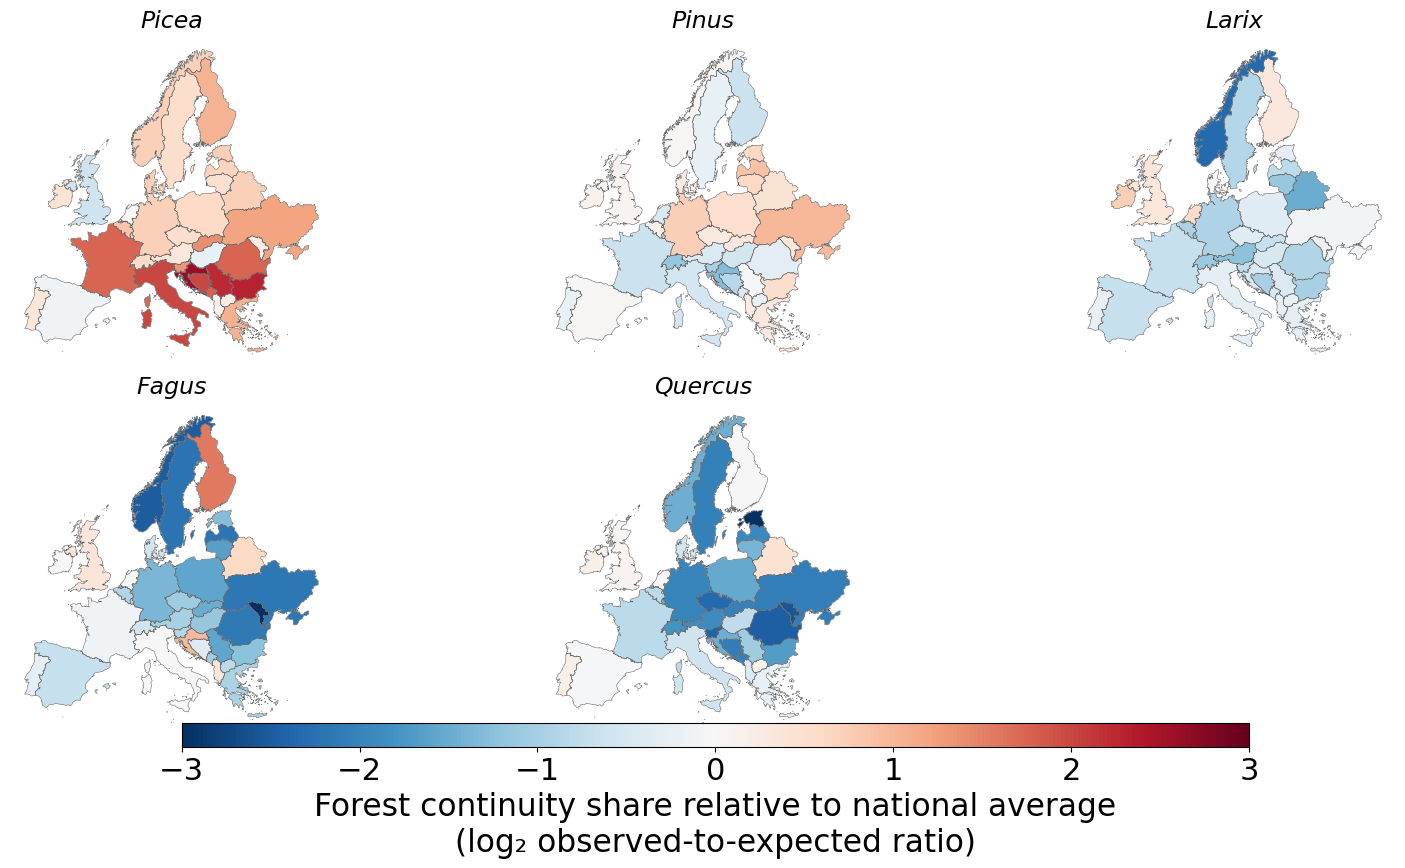

In [68]:
# ============================================================
# Country maps for selected genera
# Restricted to selected European study countries only
# ============================================================

selected_genera = [
    "Picea",
    "Pinus",
    "Larix",
    "Fagus",
    "Quercus",
]

# ------------------------------------------------------------
# Selected European countries
# ------------------------------------------------------------

european_countries = [
    "Albania",
    "Andorra",
    "Austria",
    "Belarus",
    "Belgium",
    "Bosnia and Herzegovina",
    "Bulgaria",
    "Croatia",
    "Czechia",
    "Denmark",
    "Estonia",
    "Finland",
    "France",
    "Germany",
    "Greece",
    "Hungary",
    "Ireland",
    "Italy",
    "Kosovo",
    "Latvia",
    "Liechtenstein",
    "Lithuania",
    "Luxembourg",
    "Moldova",
    "Monaco",
    "Montenegro",
    "Netherlands",
    "North Macedonia",
    "Norway",
    "Poland",
    "Portugal",
    "Romania",
    "San Marino",
    "Serbia",
    "Slovakia",
    "Slovenia",
    "Spain",
    "Sweden",
    "Switzerland",
    "Ukraine",
    "United Kingdom",
    "Vatican",
]

# ------------------------------------------------------------
# Load country geometries
# ------------------------------------------------------------

target_crs = read_first_gpkg_layer(
    HEX_GPKG
).crs

countries_map = load_countries(
    target_crs
)

name_col = find_country_name_column(
    countries_map
)

countries_map["country"] = (
    countries_map[name_col]
    .astype(str)
    .str.strip()
)

# ------------------------------------------------------------
# Keep selected countries only
# ------------------------------------------------------------

countries_map = countries_map[
    countries_map["country"].isin(
        european_countries
    )
].copy()

countries_map = countries_map[
    countries_map.geometry.notna()
    & ~countries_map.geometry.is_empty
].copy()

countries_map["geometry"] = (
    countries_map.geometry.make_valid()
)

print(
    "Selected countries found:",
    sorted(
        countries_map["country"].unique()
    )
)

print(
    "Requested countries not found:",
    sorted(
        set(european_countries)
        - set(countries_map["country"].unique())
    )
)

# ------------------------------------------------------------
# Remove overseas and remote polygon parts
# ------------------------------------------------------------

countries_4326 = countries_map.to_crs(
    "EPSG:4326"
)

country_parts = (
    countries_4326
    .explode(index_parts=False)
    .reset_index(drop=True)
)

representative_points = (
    country_parts.representative_point()
)

keep_parts = (
    (representative_points.x >= -11)
    & (representative_points.x <= 45)
    & (representative_points.y >= 34)
    & (representative_points.y <= 72)
)

country_parts = country_parts.loc[
    keep_parts
].copy()

country_parts = country_parts[
    country_parts.geometry.notna()
    & ~country_parts.geometry.is_empty
].copy()

# Recombine polygon parts by country
countries_map = country_parts.dissolve(
    by="country",
    as_index=False,
)

countries_map = countries_map.to_crs(
    target_crs
)

# ------------------------------------------------------------
# Prepare country × genus values
# ------------------------------------------------------------

country_map_values = country_genus_oe[
    [
        "country",
        "genus",
        "total_pixels",
        "country_continuity_pixels",
        "log2_ratio_smoothed",
    ]
].copy()

country_map_values["country"] = (
    country_map_values["country"]
    .astype(str)
    .str.strip()
)

# Restrict values to selected countries and genera
country_map_values = country_map_values[
    country_map_values["country"].isin(
        countries_map["country"]
    )
    & country_map_values["genus"].isin(
        selected_genera
    )
].copy()

country_genus_map = countries_map.merge(
    country_map_values,
    on="country",
    how="left",
)

# ------------------------------------------------------------
# Shared symmetric colour scale
# ------------------------------------------------------------

# ------------------------------------------------------------
# Fixed symmetric colour scale: -3 to 3
# ------------------------------------------------------------

norm = TwoSlopeNorm(
    vmin=-3,
    vcenter=0,
    vmax=3,
)

cmap = "RdBu_r"

cmap = "RdBu_r"

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(16.5, 8.8),
)

axes = np.asarray(axes).ravel()

for ax, genus in zip(
    axes,
    selected_genera,
):
    genus_map = country_genus_map[
        country_genus_map["genus"] == genus
    ].copy()

    valid = (
        (genus_map["total_pixels"] > 0)
        & (
            genus_map["country_continuity_pixels"]
            > 0
        )
        & genus_map[
            "log2_ratio_smoothed"
        ].notna()
    )

    # Base layer
    countries_map.plot(
        ax=ax,
        color="#efefef",
        edgecolor="white",
        linewidth=0.25,
        zorder=1,
    )

    # Valid country values
    genus_map.loc[valid].plot(
        ax=ax,
        column="log2_ratio_smoothed",
        cmap=cmap,
        norm=norm,
        edgecolor="white",
        linewidth=0.25,
        zorder=2,
    )

    # Country boundaries
    countries_map.boundary.plot(
        ax=ax,
        color="#555555",
        linewidth=0.35,
        zorder=3,
    )

    ax.set_title(
        genus,
        fontsize=17,
        fontstyle="italic",
        pad=5,
    )

    ax.set_axis_off()
    ax.set_aspect("equal")

# Hide unused sixth panel
for ax in axes[len(selected_genera):]:
    ax.set_visible(False)

# ------------------------------------------------------------
# Shared colour bar
# ------------------------------------------------------------

sm = ScalarMappable(
    cmap=cmap,
    norm=norm,
)

sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=axes[:len(selected_genera)].tolist(),
    orientation="horizontal",
    fraction=0.035,
    pad=0.035,
    aspect=45,
)

cbar.set_label(
    "Forest continuity share relative to national average\n"
    "(log₂ observed-to-expected ratio)",
    fontsize=22.5,
)

cbar.ax.tick_params(
    labelsize=22
)

# ------------------------------------------------------------
# Layout
# ------------------------------------------------------------

fig.subplots_adjust(
    left=0.025,
    right=0.985,
    top=0.92,
    bottom=0.12,
    wspace=0.02,
    hspace=0.08,
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

save_figure(
    fig,
    FIGURE_DIR
    / "country_relative_genus_representation_selected_genera_selected_countries"
)

plt.show()

## 6. Forest-age figures from the existing sampled data and hexagon cache

In [74]:
FOREST_AGE_SAMPLE_CSV = Path(
    "/mnt/eo/EO4Backcasting/_analysis/plausibility_checks/"
    "forest_age_continuity_vs_disturbed_after_1995_sample_v2.csv"
)

forest_age_sample = pd.read_csv(
    require_file(
        FOREST_AGE_SAMPLE_CSV,
        "Forest-age sampled data"
    )
)

print("Forest-age sample rows:", len(forest_age_sample))
print(
    "Forest-age sample columns:",
    list(forest_age_sample.columns)
)

Forest-age sample rows: 1409212
Forest-age sample columns: ['hex_id', 'forest_group', 'forest_age_years']


In [75]:
# Normalise group labels used in different versions of the sample
forest_age_sample["forest_group"] = (
    forest_age_sample["forest_group"]
    .astype(str)
    .replace({
        "Disturbed after 1995": "Other forest",
        "Disturbed forest": "Other forest",
        "Remaining forest": "Other forest",
    })
)

group_order = ["Other forest", "Continuity forest"]
group_colors = {
    "Other forest": "#9E9E9E",
    "Continuity forest": "#2E7D32",
}

plot_arrays = []
for group in group_order:
    values = (
        forest_age_sample.loc[
            forest_age_sample["forest_group"] == group,
            "forest_age_years",
        ]
        .dropna()
        .astype(float)
        .to_numpy()
    )
    values = values[np.isfinite(values)]
    if not len(values):
        raise ValueError(
            f"No observations for '{group}'. "
            f"Available groups: {forest_age_sample['forest_group'].unique()}"
        )
    plot_arrays.append(values)

median_difference = np.median(plot_arrays[1]) - np.median(plot_arrays[0])
print(f"Median difference, continuity minus other forest: {median_difference:.1f} years")


Median difference, continuity minus other forest: 54.0 years


Saved: /mnt/eo/EO4Backcasting/_figs/plotting_only_gt0729/forest_age_violin.png
Saved: /mnt/eo/EO4Backcasting/_figs/plotting_only_gt0729/forest_age_violin.svg


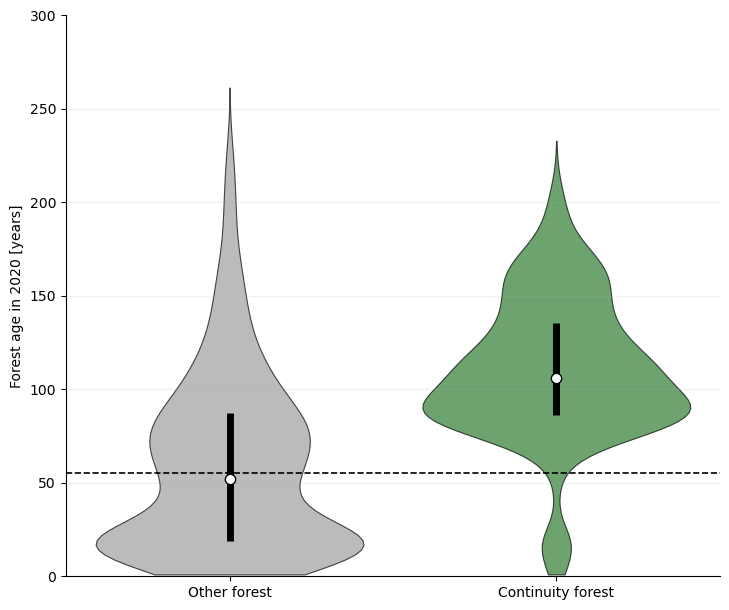

In [76]:
# Violin plot
fig, ax = plt.subplots(figsize=(7.4, 6.2))
positions = np.arange(1, 3)

parts = ax.violinplot(
    plot_arrays,
    positions=positions,
    widths=0.82,
    showmeans=False,
    showmedians=False,
    showextrema=False,
    bw_method=0.25,
)

for body, group in zip(parts["bodies"], group_order):
    body.set_facecolor(group_colors[group])
    body.set_edgecolor("black")
    body.set_linewidth(0.8)
    body.set_alpha(0.70)

for position, values in zip(positions, plot_arrays):
    q25, median, q75 = np.quantile(values, [0.25, 0.50, 0.75])
    ax.vlines(position, q25, q75, color="black", linewidth=5, zorder=3)
    ax.scatter(
        position, median, s=55, facecolor="white",
        edgecolor="black", linewidth=1, zorder=4
    )

ax.axhline(55, color="black", linestyle="--", linewidth=1.2)
ax.set_xticks(positions, group_order)
ax.set_ylabel("Forest age in 2020 [years]")
ax.set_ylim(0, 300)
ax.grid(axis="y", alpha=0.20)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()

save_figure(fig, FIGURE_DIR / "forest_age_violin")
plt.show()


In [ ]:
# Cumulative forest-age distributions
fig, ax = plt.subplots(figsize=(7.4, 6.2))

for group, values in zip(group_order, plot_arrays):
    values = np.sort(values)
    y = np.arange(1, len(values) + 1) / len(values)
    x_grid = np.linspace(0, 300, 1000)
    y_grid = np.interp(x_grid, values, y, left=0, right=1)
    ax.plot(
        x_grid,
        y_grid,
        label=group,
        color=group_colors[group],
        linewidth=2.4,
    )

ax.axvline(55, color="black", linestyle="--", linewidth=1.2)
ax.set_xlabel("Forest age in 2020 [years]")
ax.set_ylabel("Cumulative proportion")
ax.set_xlim(0, 300)
ax.set_ylim(0, 1)
ax.legend(frameon=False, loc="lower right")
ax.grid(alpha=0.20)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()

save_figure(fig, FIGURE_DIR / "forest_age_cumulative")
plt.show()


In [ ]:
# Hexagon-level relationship from the existing forest-age GeoPackage
MAIN_AGE_THRESHOLD = 55
MIN_AGE_COVERAGE_PERCENT = 80.0
MIN_COMMON_FOREST_AREA_HA = 1000.0

age_share_col = f"forest_age_ge_{MAIN_AGE_THRESHOLD}_share_percent"
continuity_share_col = "continuity_common_share_percent"

required = [
    age_share_col,
    continuity_share_col,
    "forest_age_coverage_percent",
    "common_forest_area_ha",
]
missing = [c for c in required if c not in hex_compare.columns]
if missing:
    raise ValueError(
        f"Missing columns in forest-age hexagon cache: {missing}\n"
        f"Available: {list(hex_compare.columns)}"
    )

valid = hex_compare[
    hex_compare[age_share_col].notna()
    & hex_compare[continuity_share_col].notna()
    & (
        hex_compare["forest_age_coverage_percent"]
        >= MIN_AGE_COVERAGE_PERCENT
    )
    & (
        hex_compare["common_forest_area_ha"]
        >= MIN_COMMON_FOREST_AREA_HA
    )
].copy()

rho, p_value = spearmanr(
    valid[continuity_share_col],
    valid[age_share_col],
    nan_policy="omit",
)

n_bins = min(10, valid[continuity_share_col].nunique())
valid["continuity_bin"] = pd.qcut(
    valid[continuity_share_col],
    q=n_bins,
    duplicates="drop",
)

relationship = (
    valid.groupby("continuity_bin", observed=True)
    .agg(
        continuity_median=(continuity_share_col, "median"),
        continuity_q25=(continuity_share_col, lambda x: x.quantile(0.25)),
        continuity_q75=(continuity_share_col, lambda x: x.quantile(0.75)),
        forest_age_median=(age_share_col, "median"),
        forest_age_q25=(age_share_col, lambda x: x.quantile(0.25)),
        forest_age_q75=(age_share_col, lambda x: x.quantile(0.75)),
        n_hexagons=("hex_id", "size"),
    )
    .reset_index(drop=True)
)

x = relationship["continuity_median"].to_numpy()
y = relationship["forest_age_median"].to_numpy()
xerr = np.vstack([
    x - relationship["continuity_q25"].to_numpy(),
    relationship["continuity_q75"].to_numpy() - x,
])
yerr = np.vstack([
    y - relationship["forest_age_q25"].to_numpy(),
    relationship["forest_age_q75"].to_numpy() - y,
])

fig, ax = plt.subplots(figsize=(7.5, 6.2))
ax.errorbar(x, y, xerr=xerr, yerr=yerr, marker="o", linestyle="-", capsize=3)
ax.set_xlabel(
    "Continuously undisturbed forest\n"
    "[% of common forest area; bin median and IQR]"
)
ax.set_ylabel(
    "Forest age ≥55 years\n"
    "[% of common forest area; median and IQR]"
)
ax.set_title(f"Spearman ρ = {rho:.2f}, n = {len(valid):,} hexagons")
ax.grid(alpha=0.2)
plt.tight_layout()

save_figure(fig, FIGURE_DIR / "forest_age_vs_continuity_binned")
plt.show()


## 7. Notes

- No cell in this notebook creates or modifies the binary continuity raster.
- No cell reads the full training table or applies the XGBoost model.
- No SHAP values are calculated.
- No raster-wide country, genus, hexagon, or forest-age aggregation is performed.
- The forest-age comparison uses the previously written sampled CSV.
- Missing caches raise an error and must be generated once with the complete analysis notebook.